In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats




sys.path.append('..')
import plot_settings
import importlib
import multi_exp_log

from IPython.display import display, Math
from pysr import PySRRegressor, TemplateExpressionSpec
# import mean
from pysr import jl
jl.seval("using Statistics")

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(multi_exp_log)

import_reload()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# Importing data

In [2]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [3]:


def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df


path = f'2_merged_data'

data = read_data(path)
display(data.head())


,u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
0,0.4,2.2,0.0,4.239833,10.952074,0.030566,-0.057493,4.324996,-0.085164,0,-0.027881,-0.000470,0.999389
1,0.4,2.2,1.0,4.211952,10.952074,0.030096,-0.057493,4.323139,-0.111187,0,-0.016738,-0.000471,0.998778
2,0.4,2.2,2.0,4.195213,10.952074,0.029624,-0.057493,4.321278,-0.126065,0,-0.011734,-0.000471,0.998167
3,0.4,2.2,3.0,4.183479,10.952074,0.029153,-0.057493,4.319417,-0.135938,0,-0.006706,-0.000471,0.997556
4,0.4,2.2,4.0,4.176773,10.952074,0.028682,-0.057493,4.317557,-0.140783,0,-0.005763,-0.000471,0.996944


To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

## The sampled terrain

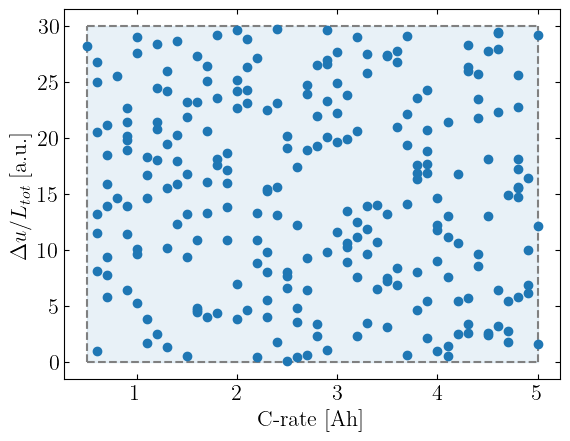

In [4]:
u_C_pairs = data.loc[data['t'] == 0, ['u_par', 'C']]
plt.xlabel('C-rate [Ah]')
plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

# Plotting data

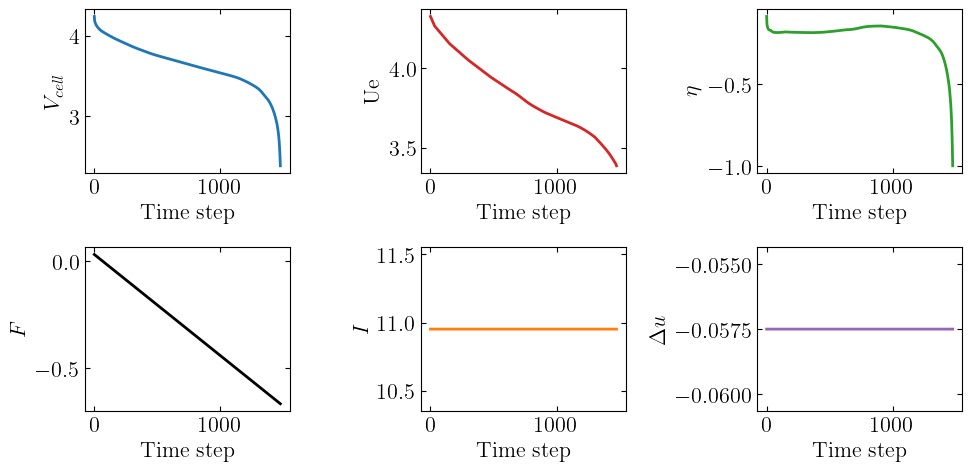

In [5]:

plot_idx = data['trajectory'] == 0
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data['V'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data['Ue'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('Ue')
ax[0,2].plot(data['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data['F'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn.functional as TF

def soc_force_func(soc, variable = 'F'):   
    if variable == 'F': 
        forcing_const = 0.995
    elif variable == 'U':
        forcing_const = 0.995
    return 1 - np.exp(-(1-soc) / (1 - forcing_const));

class MyModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=256): 
        super(MyModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        
        if True:
            Fs_raw = self.net(x)[:,0] #* force_func(soc)  # (T,)
            U1_raw = self.net(x)[:,1] 
            soc = x[:,2]
            Fs = soc_force_func(soc, variable='F') * Fs_raw;
            U1 = soc_force_func(soc, variable = 'U') * TF.softplus(U1_raw);
            
            return Fs, U1
        else:
            R0_raw, Fs_raw, U1_raw = self.net(x)[:,0], self.net(x)[:,1], self.net(x)[:,2]
            R0 = R0_raw#torch.clamp(R0_raw, 0, 1) #TF.softplus(R0_raw)  # Ensure R0 is non-negative
            Fs = Fs_raw#force_func(soc) * Fs_raw
            U1 = U1_raw # torch.clamp(U1_raw, 0, 1) #TF.softplus(U1_raw)  # Ensure U1 is non-negative

            return R0, Fs, U1

In [7]:
def load_saved_model(path = 'JH_model_8_N248'):
    m = MyModel()
    m.load_state_dict(torch.load(f'multi_models/{path}.pth'))
    m.eval()
    return m

N_trajs = len(data['trajectory'].unique())


X = data[['I','u','soc','Ue','trajectory']].values
y = data[['V','F','trajectory']].values


x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')

NN_model = load_saved_model()


Number of trajectories in train: 198 out of 248
X shape torch.Size([415557, 5])	y shape torch.Size([415557, 3])
X-train shape: torch.Size([334590, 5])	y-train shape: torch.Size([334590, 3])
X-test shape: torch.Size([80967, 5])	y-test shape: torch.Size([80967, 3])


In [8]:
print(len(x_train[:,0]))
U1_data = np.zeros((len(x_train[:,0]),6))
    # (N_trajs*0.8, T)
for x_traj in trange(int(N_trajs *0.8)):
    traj_idx = x_train[:,-1] == x_traj
    #print(f'Trajectory {x_traj} has {traj_idx.sum()} time steps')
    # save I,u,soc, and NN_model(X_traj) for each trajectory
    NN_input = x_train[traj_idx,:]
    U1_data[traj_idx,0] =  NN_model(NN_input[:,:3])[1].detach().numpy()  # (T,)
    U1_data[traj_idx,1] =  NN_input[:,0].detach().numpy()  # I
    U1_data[traj_idx,2] =  NN_input[:,1].detach().numpy()  # u
    U1_data[traj_idx,3] =  NN_input[:,2].detach().numpy()  # soc
    U1_data[traj_idx,4] =  np.concat((np.diff(U1_data[traj_idx,0]),[np.diff(U1_data[traj_idx,0])[-1]] ))  # dU1/dt
    U1_data[traj_idx,5] =  x_train[traj_idx,-1].detach().numpy()  # trajectory index

print(U1_data.shape)  # (N_trajs*0.8, T)

df = pd.DataFrame(U1_data, columns=['U1', 'I', 'u', 'soc', 'dU1','trajectory'])
#df.to_csv('multi_models/U1_data.csv', index=False)
df.head()

334590


  0%|          | 0/198 [00:00<?, ?it/s]/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_783/3521825897.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 - np.exp(-(1-soc) / (1 - forcing_const));
100%|██████████| 198/198 [00:02<00:00, 80.89it/s]

(334590, 6)


,U1,I,u,soc,dU1,trajectory
0,0.011041,10.952074,-0.057493,0.999389,0.009767,0.0
1,0.020808,10.952074,-0.057493,0.998778,0.008641,0.0
2,0.029449,10.952074,-0.057493,0.998167,0.007644,0.0
3,0.037092,10.952074,-0.057493,0.997556,0.006761,0.0
4,0.043853,10.952074,-0.057493,0.996944,0.005980,0.0


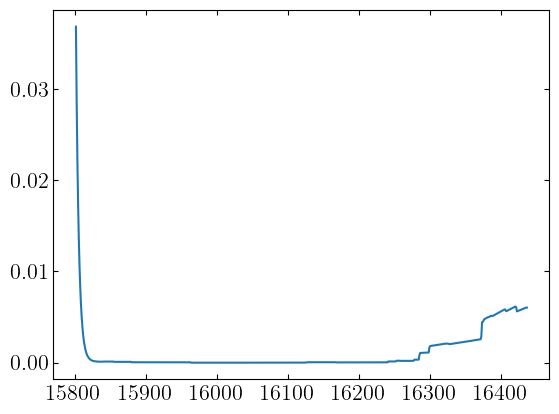

In [9]:
plt.plot(df['dU1'][df['trajectory'] == 6], label='dU1/dt')

# ECM equation

I want to solve $$V_{terminal} = U_{eq} - iR_0-U_1,\quad\mathrm{where}\quad \frac{dU_1}{dt} = \frac{U_1}{R_1C_1} - \frac{i}{C_1}. $$

In [10]:
def get_U1_dU1_dt(I,u,soc, Q = Q0):
    model_input = torch.tensor([[I,u,soc]], dtype=torch.float32)
    U1 = NN_model(model_input)[1].detach().numpy()[0]
    dsoc = soc - 0.01
    dt = dsoc * Q / I 
    model_input = torch.tensor([[I,u,dsoc]], dtype=torch.float32)
    dU1 = U1 - NN_model(model_input)[1].detach().numpy()[0]
    du1_dt = dU1 / dt
    return U1, du1_dt


U1, dU1_dt = get_U1_dU1_dt(I=11, u=-0.5, soc=0.8)
print(f'U1: {U1:.5f}, dU1/dt: {dU1_dt:.5e}')

/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_783/3521825897.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 - np.exp(-(1-soc) / (1 - forcing_const));


U1: 0.08791, dU1/dt: 3.92704e-07


In [11]:
template = TemplateExpressionSpec(
    expressions=['f', 'g'],
    variable_names= ['x1', 'x2', 'x3','x4'],   
    combine = 'x1 / ((f(x2, x3, x4))^2 * (g(x2, x3, x4))^2) - x2 / (g(x2, x3, x4))^2'
)

In [12]:
df.head()

,U1,I,u,soc,dU1,trajectory
0,0.011041,10.952074,-0.057493,0.999389,0.009767,0.0
1,0.020808,10.952074,-0.057493,0.998778,0.008641,0.0
2,0.029449,10.952074,-0.057493,0.998167,0.007644,0.0
3,0.037092,10.952074,-0.057493,0.997556,0.006761,0.0
4,0.043853,10.952074,-0.057493,0.996944,0.005980,0.0


In [17]:
inds = U1_data[:,-1] < int(N_trajs * 0.005)
print(int(N_trajs * 0.005))
X_data = U1_data[inds,:-2]  # I,u,soc,dU1/dt

Y_data = U1_data[inds,-2]  


print(f'X_data shape: {X_data.shape}')
print(f'Y_data shape: {Y_data.shape}')

1
X_data shape: (4315, 4)
Y_data shape: (4315,)


In [18]:
model = PySRRegressor(
    model_selection="score",
    niterations=250,
    binary_operators=[
        "+", "*", '-','/'
    ],
    unary_operators=['sqrt','square', 'cube'],
    elementwise_loss="loss(x, y) = (x - y)^2",
    populations=10,
    verbosity=1, 
    expression_spec=template, batch_size= 128
)


In [ ]:
model.fit(X_data, Y_data)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...


Text(0.5, 1.0, 'Model Complexity vs Loss')

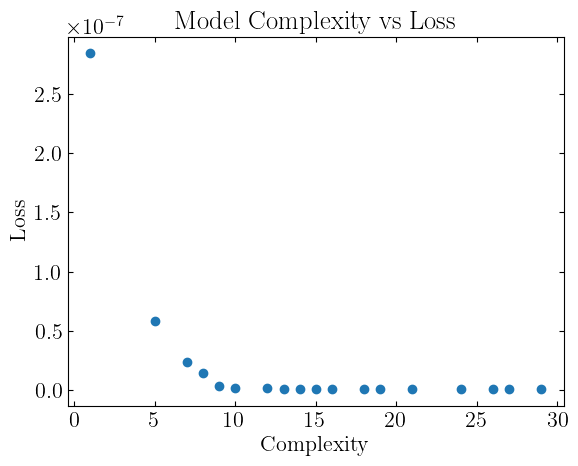

In [13]:
df_model = model.equations_

plt.scatter(df_model['complexity'], df_model['loss'])
plt.xlabel('Complexity')
plt.ylabel('Loss')
plt.title('Model Complexity vs Loss')

In [14]:
model_index = None
display(Math(f'\\LARGE {model.latex(model_index)}'))
print(f'Best model in symbolic form: {model.sympy()}')

<IPython.core.display.Math object>

Best model in symbolic form: x0*(-0.0001887521) - 7.049519e-5*x1 + 0.008446693


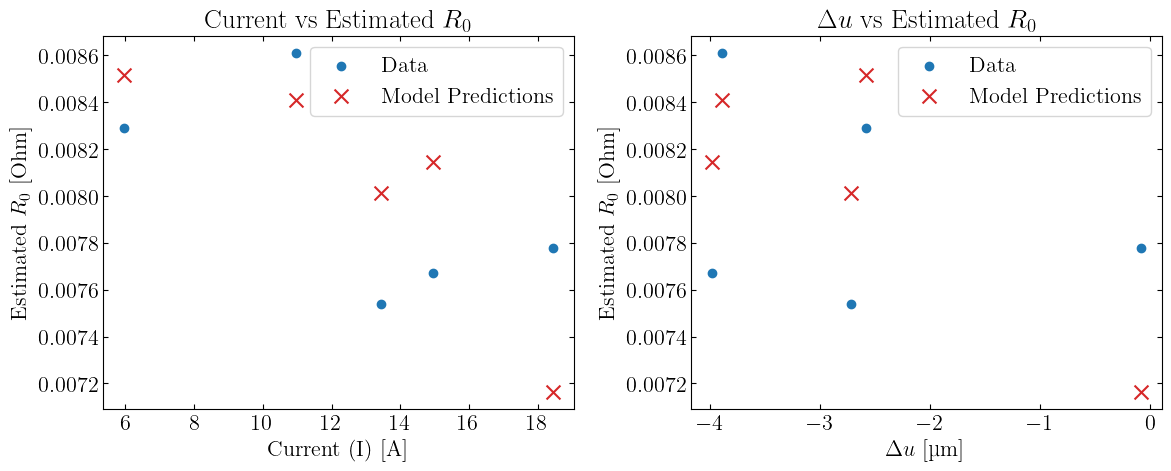

In [162]:
rand_samples = np.random.choice(len(u),size=5, replace=False)
I_test = I[rand_samples]
u_test = u[rand_samples]
R0_test = R0_est[:5]
R0_pred = model.predict(np.vstack((u_test, I_test)).T)

f, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(I_test, R0_test, label='Data', color=colors[0])
ax[0].scatter(I_test, R0_pred, label='Model Predictions', color=colors[1], marker='x', s=100)
ax[0].set_xlabel('Current (I) [A]')
ax[0].set_ylabel('Estimated $R_0$ [Ohm]')
ax[0].set_title('Current vs Estimated $R_0$')
ax[0].legend()
ax[1].scatter(u_test, R0_test, label='Data', color=colors[0])
ax[1].scatter(u_test, R0_pred, label='Model Predictions', color=colors[1], marker='x', s=100)
ax[1].set_xlabel(r'$\Delta u$ [µm]')
ax[1].set_ylabel('Estimated $R_0$ [Ohm]')
ax[1].set_title(r'$\Delta u$ vs Estimated $R_0$')
ax[1].legend()
plt.tight_layout()
plt.show()

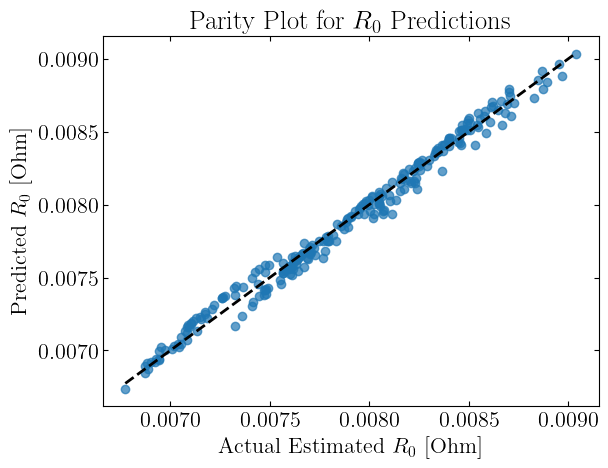

In [33]:
# Parity plot
R0_pred = model.predict(X_data)
plt.scatter(R0_est, R0_pred, color=colors[0],alpha = 0.7)
plt.plot([R0_est.min(), R0_est.max()], [R0_est.min(), R0_est.max()], 'k--', lw=2)
plt.xlabel('Actual Estimated $R_0$ [Ohm]')
plt.ylabel('Predicted $R_0$ [Ohm]')
plt.title('Parity Plot for $R_0$ Predictions')
plt.show()

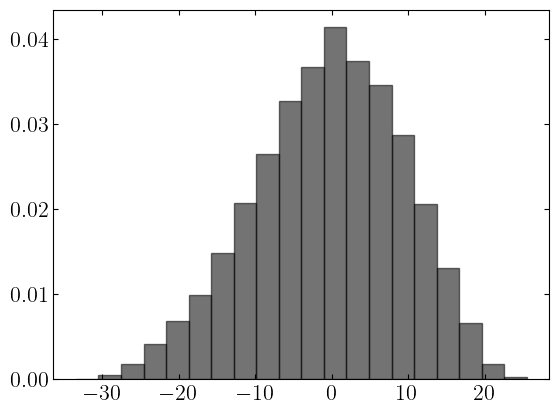

In [164]:
plt.hist(100 * (1  - R0_pred / R0_est).ravel(), bins=20, color=colors[3], edgecolor='k', alpha=0.55, density=True)
plt.show()

Text(0.5, 1.0, 'Estimated R0 vs SoC')

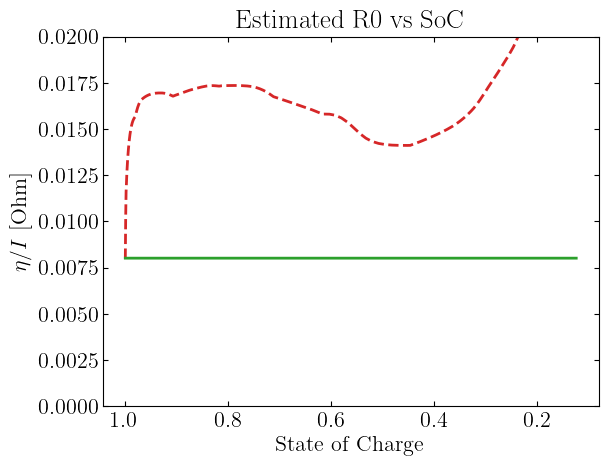

In [32]:
plot_idx = 8

plt.plot(data['soc'][data['trajectory'] == plot_idx], -data['eta'][data['trajectory'] == plot_idx] / data['I'][data['trajectory'] == plot_idx], '--', color = colors[1], lw = 2,alpha=1)
plt.plot(data['soc'][data['trajectory'] == plot_idx], model.predict(np.vstack((data['u'][data['trajectory'] == plot_idx], data['I'][data['trajectory'] == plot_idx])).T), '-', color = colors[2], lw = 2,alpha=1)

plt.ylim(0.0,.02)
plt.gca().invert_xaxis()
plt.xlabel('State of Charge')
plt.ylabel(r'$\eta / I$ [Ohm]')
plt.title('Estimated R0 vs SoC')